# Model Diagnostics and Calibration

This notebook tests where the selected CatBoost models work, where they remain unreliable, and whether a simple calibration correction improves future-season probabilities.

The 2024-25 final holdout is not loaded.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.catboost_model import fit_catboost_classifier
from src.diagnostics import (
    distance_bands,
    history_aware_identity_predictions,
    period_clock_bands,
    player_volume_groups,
    segment_metrics,
)
from src.features import build_features, extract_target
from src.modeling import (
    apply_platt_calibrator,
    calibration_table,
    evaluate_probabilities,
    fit_platt_calibrator,
)

pd.set_option("display.float_format", lambda value: f"{value:,.5f}")
sns.set_theme(style="whitegrid")

## 1. Recreate out-of-time CatBoost predictions

Both depth-5 variants use the settings selected in the CatBoost notebook. Recreating predictions here makes this notebook independently executable.

In [2]:
season_paths = {
    "2021-22": PROJECT_ROOT / "data" / "raw" / "2021.parquet",
    "2022-23": PROJECT_ROOT / "data" / "raw" / "2022.parquet",
    "2023-24": PROJECT_ROOT / "data" / "raw" / "2023.parquet",
}
raw_by_season = {label: pd.read_parquet(path) for label, path in season_paths.items()}
folds = [
    {"fold": "2021-22 to 2022-23", "train": ["2021-22"], "validation": "2022-23"},
    {"fold": "2021-23 to 2023-24", "train": ["2021-22", "2022-23"], "validation": "2023-24"},
]
MINIMUM_IDENTITY_HISTORY = 250
CATBOOST_SETTINGS = {
    "depth": 5,
    "iterations": 1200,
    "learning_rate": 0.05,
    "l2_leaf_reg": 5.0,
    "early_stopping_rounds": 60,
    "random_seed": 42,
}
CATBOOST_SETTINGS

{'depth': 5,
 'iterations': 1200,
 'learning_rate': 0.05,
 'l2_leaf_reg': 5.0,
 'early_stopping_rounds': 60,
 'random_seed': 42}

In [3]:
fold_artifacts = {}
overall_records = []

for fold in folds:
    train_raw = pd.concat([raw_by_season[label] for label in fold["train"]], ignore_index=True)
    validation_raw = raw_by_season[fold["validation"]].reset_index(drop=True)
    y_train = extract_target(train_raw)
    y_validation = extract_target(validation_raw)

    x_train_context = build_features(train_raw)
    x_validation_context = build_features(validation_raw)
    context_model = fit_catboost_classifier(
        x_train_context, y_train, x_validation_context, y_validation, **CATBOOST_SETTINGS
    )
    context_predictions = context_model.predict_proba(x_validation_context)[:, 1]

    x_train_identity = build_features(train_raw, include_identity=True)
    x_validation_identity = build_features(validation_raw, include_identity=True)
    identity_model = fit_catboost_classifier(
        x_train_identity,
        y_train,
        x_validation_identity,
        y_validation,
        include_identity=True,
        **CATBOOST_SETTINGS,
    )
    identity_predictions = identity_model.predict_proba(x_validation_identity)[:, 1]
    history_aware_predictions = history_aware_identity_predictions(
        context_predictions,
        identity_predictions,
        train_raw,
        validation_raw,
        minimum_training_attempts=MINIMUM_IDENTITY_HISTORY,
    )

    for model_name, predictions in [
        ("CatBoost context", context_predictions),
        ("CatBoost identity", identity_predictions),
        ("CatBoost history-aware", history_aware_predictions),
    ]:
        overall_records.append(
            {"fold": fold["fold"], "model": model_name, **evaluate_probabilities(y_validation, predictions)}
        )

    fold_artifacts[fold["fold"]] = {
        "train_raw": train_raw,
        "validation_raw": validation_raw,
        "target": y_validation,
        "context_predictions": context_predictions,
        "identity_predictions": identity_predictions,
        "history_aware_predictions": history_aware_predictions,
        "context_best_iteration": context_model.get_best_iteration() + 1,
        "identity_best_iteration": identity_model.get_best_iteration() + 1,
    }

overall_results = pd.DataFrame(overall_records)
overall_results

,fold,model,log_loss,brier_score,ece
0,2021-22 to 2022-23,CatBoost context,0.63513,0.22342,0.00938
1,2021-22 to 2022-23,CatBoost identity,0.63504,0.22333,0.01617
2,2021-22 to 2022-23,CatBoost history-aware,0.63433,0.22303,0.00727
3,2021-23 to 2023-24,CatBoost context,0.63558,0.22366,0.00562
4,2021-23 to 2023-24,CatBoost identity,0.63432,0.22306,0.01183
5,2021-23 to 2023-24,CatBoost history-aware,0.63389,0.22289,0.00580


## 2. Test calibration and the player-history rule

The history-aware rule uses context predictions for players with fewer than 250 training attempts and identity predictions otherwise. It is accepted only if it improves raw identity log loss in both folds. A one-variable Platt calibrator is then fitted on 2022-23 history-aware predictions made from 2021-22 training and applied unchanged to 2023-24. Calibration is accepted only if it improves 2023-24 log loss, Brier score, and ECE together.

In [4]:
first_fold_name = folds[0]["fold"]
latest_fold_name = folds[1]["fold"]
first_artifact = fold_artifacts[first_fold_name]
latest_artifact = fold_artifacts[latest_fold_name]

overall_log_loss = overall_results.pivot(index="fold", columns="model", values="log_loss")
history_aware_improvements = overall_log_loss["CatBoost identity"] - overall_log_loss["CatBoost history-aware"]
history_aware_accepted = bool((history_aware_improvements > 0).all())

platt_calibrator = fit_platt_calibrator(
    first_artifact["history_aware_predictions"], first_artifact["target"]
)
latest_calibrated_predictions = apply_platt_calibrator(
    platt_calibrator, latest_artifact["history_aware_predictions"]
)

calibration_records = []
for model_name, predictions in [
    ("Context", latest_artifact["context_predictions"]),
    ("Identity raw", latest_artifact["identity_predictions"]),
    ("History-aware raw", latest_artifact["history_aware_predictions"]),
    ("History-aware + temporal Platt", latest_calibrated_predictions),
]:
    calibration_records.append(
        {"model": model_name, **evaluate_probabilities(latest_artifact["target"], predictions)}
    )
calibration_comparison = pd.DataFrame(calibration_records).set_index("model")

raw_metrics = calibration_comparison.loc["History-aware raw"]
calibrated_metrics = calibration_comparison.loc["History-aware + temporal Platt"]
calibration_accepted = bool((calibrated_metrics < raw_metrics).all())

display(calibration_comparison)
pd.Series(
    {
        "history_aware_improvement_fold_1": history_aware_improvements.iloc[0],
        "history_aware_improvement_fold_2": history_aware_improvements.iloc[1],
        "history_aware_accepted": history_aware_accepted,
        "platt_slope": platt_calibrator.coef_[0, 0],
        "platt_intercept": platt_calibrator.intercept_[0],
        "calibration_accepted": calibration_accepted,
    }
)

,log_loss,brier_score,ece
model,,,
Context,0.63558,0.22366,0.00562
Identity raw,0.63432,0.22306,0.01183
History-aware raw,0.63389,0.22289,0.00580
History-aware + temporal Platt,0.63394,0.22290,0.00633


history_aware_improvement_fold_1   0.00071
history_aware_improvement_fold_2   0.00042
history_aware_accepted                True
platt_slope                        1.02251
platt_intercept                    0.03432
calibration_accepted                 False
dtype: object

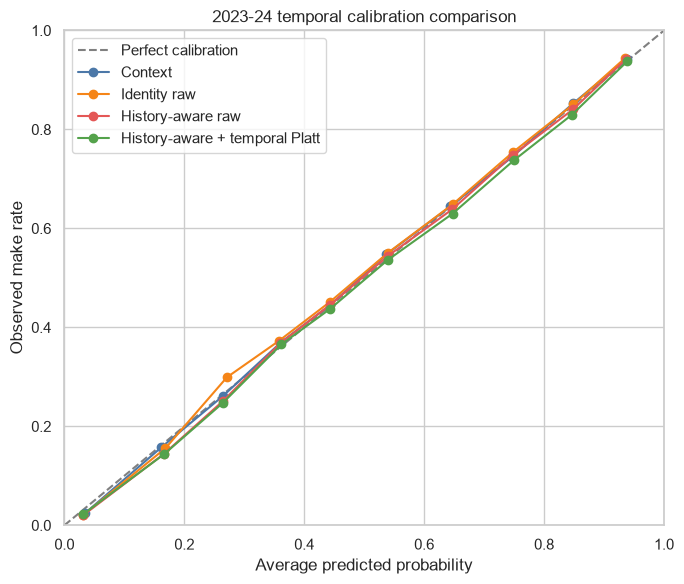

In [5]:
plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")

for model_name, predictions, color in [
    ("Context", latest_artifact["context_predictions"], "#4c78a8"),
    ("Identity raw", latest_artifact["identity_predictions"], "#f58518"),
    ("History-aware raw", latest_artifact["history_aware_predictions"], "#e45756"),
    ("History-aware + temporal Platt", latest_calibrated_predictions, "#54a24b"),
]:
    table = calibration_table(latest_artifact["target"], predictions).query("shots > 0")
    plt.plot(table["average_prediction"], table["observed_make_rate"], marker="o", label=model_name, color=color)

plt.xlabel("Average predicted probability")
plt.ylabel("Observed make rate")
plt.title("2023-24 temporal calibration comparison")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## 3. Does identity help players with different history levels?

Validation players are grouped only by attempts available in that fold's training seasons. `Unseen` therefore means the model had no earlier shot record for that player.

In [6]:
player_volume_records = []
for fold in folds:
    artifact = fold_artifacts[fold["fold"]]
    volume_groups = player_volume_groups(artifact["train_raw"], artifact["validation_raw"] )
    for model_name, predictions in [
        ("Context", artifact["context_predictions"]),
        ("Identity", artifact["identity_predictions"]),
        ("History-aware", artifact["history_aware_predictions"]),
    ]:
        summary = segment_metrics(artifact["target"], predictions, volume_groups)
        summary["fold"] = fold["fold"]
        summary["model"] = model_name
        player_volume_records.append(summary)

player_volume_results = pd.concat(player_volume_records, ignore_index=True)
player_log_loss = player_volume_results.pivot(
    index=["fold", "segment"], columns="model", values="log_loss"
).reset_index()
player_log_loss["identity_improvement_over_context"] = player_log_loss["Context"] - player_log_loss["Identity"]
player_log_loss["history_aware_improvement_over_identity"] = player_log_loss["Identity"] - player_log_loss["History-aware"]
player_log_loss

model,fold,segment,Context,History-aware,Identity,identity_improvement_over_context,history_aware_improvement_over_identity
0,2021-22 to 2022-23,Unseen,0.62998,0.62998,0.63397,-0.00398,0.00398
1,2021-22 to 2022-23,1-249,0.62313,0.62313,0.62597,-0.00284,0.00284
2,2021-22 to 2022-23,250-749,0.63097,0.63067,0.63067,0.00030,0.00000
3,2021-22 to 2022-23,750+,0.64439,0.64260,0.64260,0.00179,0.00000
4,2021-23 to 2023-24,Unseen,0.62332,0.62332,0.62888,-0.00556,0.00556
5,2021-23 to 2023-24,1-249,0.62593,0.62593,0.62519,0.00074,-0.00074
6,2021-23 to 2023-24,250-749,0.62078,0.61944,0.61944,0.00134,0.00000
7,2021-23 to 2023-24,750+,0.64081,0.63874,0.63874,0.00207,0.00000


## 4. Basketball-segment diagnostics

The latest development fold is inspected by distance, court zone, action type, and period-clock context. These tables describe reliability; they are not used for a new broad tuning search.

In [7]:
latest_raw = latest_artifact["validation_raw"]
latest_target = latest_artifact["target"]
diagnostic_predictions = (
    latest_calibrated_predictions
    if calibration_accepted
    else latest_artifact["history_aware_predictions"]
    if history_aware_accepted
    else latest_artifact["identity_predictions"]
)
diagnostic_model_name = (
    "History-aware + temporal Platt"
    if calibration_accepted
    else "History-aware raw"
    if history_aware_accepted
    else "Identity raw"
)

segment_definitions = {
    "Distance": distance_bands(latest_raw),
    "Shot zone": latest_raw["SHOT_ZONE_BASIC"].rename("shot_zone"),
    "Period clock": period_clock_bands(latest_raw),
    "Action type": latest_raw["ACTION_TYPE"].rename("action_type"),
}
segment_records = []
for segment_type, segments in segment_definitions.items():
    minimum_shots = 1_000 if segment_type == "Action type" else 1
    summary = segment_metrics(
        latest_target, diagnostic_predictions, segments, minimum_shots=minimum_shots
    )
    summary["segment_type"] = segment_type
    segment_records.append(summary)

latest_segment_results = pd.concat(segment_records, ignore_index=True)

for segment_type in ["Distance", "Shot zone", "Period clock"]:
    print(segment_type)
    display(latest_segment_results.query("segment_type == @segment_type").drop(columns="segment_type"))

Distance


,segment,shots,observed_make_rate,average_prediction,log_loss,brier_score,calibration_gap,absolute_calibration_gap
0,0-4,72835,0.63853,0.63912,0.58038,0.20003,0.00060,0.00060
1,5-9,25984,0.43042,0.43150,0.66661,0.23719,0.00108,0.00108
2,10-14,17941,0.44501,0.43741,0.68143,0.24432,-0.00761,0.00761
3,15-19,12648,0.42188,0.41570,0.67746,0.24226,-0.00619,0.00619
4,20-24,33387,0.38548,0.37914,0.66482,0.23603,-0.00634,0.00634
5,25-29,53878,0.36078,0.35352,0.65218,0.22987,-0.00726,0.00726
6,30-39,1529,0.26684,0.27763,0.55927,0.18866,0.01079,0.01079
7,40-49,219,0.03653,0.04937,0.16296,0.03639,0.01284,0.01284
8,50+,280,0.01429,0.02678,0.07324,0.01385,0.01249,0.01249


Shot zone


,segment,shots,observed_make_rate,average_prediction,log_loss,brier_score,calibration_gap,absolute_calibration_gap
9,Above the Break 3,63770,0.35971,0.35253,0.65044,0.22914,-0.00719,0.00719
10,Backcourt,433,0.01848,0.02666,0.09005,0.01794,0.00818,0.00818
11,In The Paint (Non-RA),43089,0.44053,0.43926,0.67066,0.23912,-0.00127,0.00127
12,Left Corner 3,11523,0.38601,0.38649,0.66481,0.23605,0.00047,0.00047
13,Mid-Range,24590,0.41858,0.40934,0.67489,0.24104,-0.00924,0.00924
14,Restricted Area,64669,0.66313,0.66489,0.56989,0.19555,0.00176,0.00176
15,Right Corner 3,10627,0.39381,0.38392,0.66883,0.23798,-0.00989,0.00989


Period clock


,segment,shots,observed_make_rate,average_prediction,log_loss,brier_score,calibration_gap,absolute_calibration_gap
16,0-5 sec,5017,0.30975,0.30192,0.52946,0.17849,-0.00782,0.00782
17,6-24 sec,4211,0.44930,0.44876,0.61237,0.21267,-0.00054,0.00054
18,25-119 sec,30144,0.46805,0.47099,0.62878,0.22032,0.00294,0.00294
19,2-5:59,71936,0.47784,0.47671,0.63782,0.22455,-0.00113,0.00113
20,6-12:00,107393,0.48243,0.47602,0.63842,0.22497,-0.00641,0.00641


In [8]:
action_results = latest_segment_results.query("segment_type == 'Action type'").copy()
weak_action_calibration = action_results.nlargest(10, "absolute_calibration_gap")[
    ["segment", "shots", "observed_make_rate", "average_prediction", "calibration_gap", "log_loss"]
]
weak_action_calibration

,segment,shots,observed_make_rate,average_prediction,calibration_gap,log_loss
34,Hook Shot,1900,0.46316,0.50201,0.03885,0.68795
38,Putback Layup Shot,3783,0.65319,0.69051,0.03732,0.61672
49,Turnaround Jump Shot,2928,0.40266,0.42687,0.02421,0.66313
43,Running Layup Shot,7215,0.59113,0.61377,0.02264,0.63266
31,Dunk Shot,1455,0.87698,0.85619,-0.02078,0.34137
28,Driving Hook Shot,1586,0.42938,0.44818,0.01880,0.67376
35,Jump Shot,63313,0.37648,0.36045,-0.01603,0.65871
24,Driving Dunk Shot,2100,0.80714,0.82253,0.01538,0.44235
48,Turnaround Hook Shot,2394,0.49165,0.50693,0.01528,0.68354
42,Running Jump Shot,5766,0.39802,0.41155,0.01352,0.67115


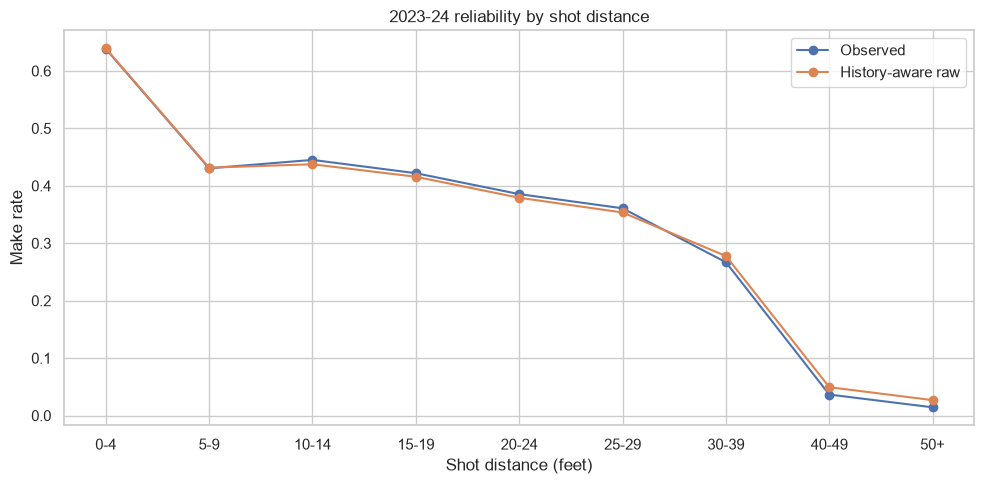

In [9]:
distance_results = latest_segment_results.query("segment_type == 'Distance'").copy()
plt.figure(figsize=(10, 5))
plt.plot(distance_results["segment"].astype(str), distance_results["observed_make_rate"], marker="o", label="Observed")
plt.plot(distance_results["segment"].astype(str), distance_results["average_prediction"], marker="o", label=diagnostic_model_name)
plt.xlabel("Shot distance (feet)")
plt.ylabel("Make rate")
plt.title("2023-24 reliability by shot distance")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Diagnostic results

- Raw identity features were not reliable for players with little history. Identity worsened log loss for unseen players by 0.00398 and 0.00556 across the two folds, and it also hurt the 1-249-attempt group in the first fold.
- A fixed history-aware rule was accepted: use context predictions below 250 prior training attempts and identity predictions otherwise. It improved overall identity log loss by 0.00071 and 0.00042, producing fold log losses of 0.63433 and 0.63389.
- The history-aware rule also improved calibration. Fold ECE fell from 0.01617 to 0.00727 and from 0.01183 to 0.00580 compared with raw identity CatBoost.
- Temporal Platt calibration was rejected. On 2023-24 it changed history-aware log loss from 0.63389 to 0.63394, Brier score from 0.22289 to 0.22290, and ECE from 0.00580 to 0.00633, making all three metrics slightly worse.
- The selected uncalibrated history-aware model is well aligned across common distance, zone, and game-clock segments. Most absolute calibration gaps are below one percentage point.
- Remaining weaknesses are concentrated in narrower action labels. Hook shots and putback layups are overpredicted by about 3.9 and 3.7 percentage points, respectively, in 2023-24. Special action-level recalibration is rejected because it would add unstable category-specific corrections without another future season for validation.
- Feature importance remains directionally sensible: action type and distance dominate, while player identity is secondary. Importance is descriptive and not causal.
- Final design: combine depth-5 context and identity CatBoost models with the fixed 250-attempt history rule and do not apply Platt calibration.